# 📊 Matplotlib 기초 — 핵심 개념 복습 노트

**학습 범위**
- 17_01 선 그래프와 그래프 완성
- 17_02 분포·범주·관계 시각화

> 강의자료의 흐름과 용어를 기준으로, 나중에 빠르게 복습할 수 있도록  
> **목차 → 한눈에 보는 코드 → 개념 → 코드 예시 → 실수 포인트 → 셀프 체크** 순서로 정리했습니다.

In [ ]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

## 1. 📌 한 줄 요약 (Executive Summary)

Matplotlib 시각화의 핵심은 **“무엇을 알고 싶은가?”에 따라 알맞은 그래프를 고르고, 제목·축·범례를 붙여 읽을 수 있는 그래프로 완성하는 것**입니다.

- **시간 변화** → 선 그래프 `plot()`
- **범주 비교** → 막대 그래프 `bar()`, `barh()`
- **값의 분포** → 히스토그램 `hist()`
- **두 값의 관계** → 산점도 `scatter()`

그리고 그래프 작성 순서는 **figure → plot/bar/hist/scatter → 꾸미기 → savefig → show** 흐름으로 기억하면 됩니다.

## 2. 🗂️ 핵심 목차 및 개요

- **A. 시각화 기본**
  - 숫자표보다 그래프가 필요한 이유
  - `matplotlib`과 `pyplot`
  - 그래프 작성 기본 흐름
  - 한글 폰트 설정
- **B. 선 그래프**
  - `plt.plot()`
  - `color`, `linestyle`, `marker`
  - 여러 선 겹쳐 그리기
  - `label`과 `legend`
- **C. 그래프 완성**
  - `title`, `xlabel`, `ylabel`
  - `xticks`
  - `figure(figsize=...)`
  - `grid`
  - `savefig`
- **D. 범주 비교**
  - `bar`, `barh`
  - 막대 색·너비
  - 긴 범주 이름 처리
- **E. 분포 확인**
  - `hist`
  - `bins`
  - 중심·퍼짐·동떨어진 값 해석
- **F. 두 변수 관계**
  - `scatter`
  - `color`, `s`, `alpha`
  - `axhline`, `axvline`
  - 상관 패턴 해석
- **G. 시각화 리포트**
  - `subplot`
  - `suptitle`
  - `tight_layout`
  - 전처리 → 시각화 검증 → 리포트

## 3. 💻 한눈에 보는 코드 정리

| 코드 | 무엇을 하는가 | 꼭 기억할 포인트 |
|---|---|---|
| `import matplotlib.pyplot as plt` | pyplot 불러오기 | `plt`는 관례적으로 쓰는 별칭 |
| `plt.plot(x, y)` | 선 그래프 | `x`, `y` 개수 같아야 함 |
| `plt.bar(x, y)` | 세로 막대 그래프 | 범주별 값 비교 |
| `plt.barh(x, y)` | 가로 막대 그래프 | 항목명이 길거나 많을 때 유용 |
| `plt.hist(data, bins=10)` | 히스토그램 | 숫자값의 분포 확인 |
| `plt.scatter(x, y)` | 산점도 | 두 변수의 관계 확인 |
| `color='red'` | 색 지정 | 문자열로 작성 |
| `linestyle='--'` | 점선 | 선 그래프 구분에 유용 |
| `marker='o'` | 데이터 점 표시 | 실제 측정 위치를 보기 좋게 |
| `label='A호기'` | 선 이름 저장 | 이것만으로 범례는 안 보임 |
| `plt.legend()` | 범례 표시 | `label`과 짝 |
| `plt.legend(loc='upper left')` | 범례 위치 지정 | 데이터와 덜 겹치는 곳 선택 |
| `plt.title('제목')` | 그래프 제목 | 설비명·값·기준이 드러나면 좋음 |
| `plt.xlabel('일자')` | x축 이름 | 의미를 명확히 |
| `plt.ylabel('온도(℃)')` | y축 이름 | 단위까지 쓰면 좋음 |
| `plt.xticks(...)` | x축 눈금 표시 변경 | 위치와 글자 개수 맞추기 |
| `plt.figure(figsize=(10, 4))` | 그래프 크기 | **plot보다 먼저** |
| `plt.grid(True, alpha=0.3)` | 격자 표시 | 보조선은 흐리게 |
| `plt.axhline(y=4.0)` | 수평 기준선 | 임계값 표시 |
| `plt.axvline(x=...)` | 수직 기준선 | x축 임계값 표시 |
| `plt.subplot(2, 2, 1)` | 한 화면을 여러 칸으로 나눔 | 칸 번호는 **1부터** |
| `plt.suptitle('전체 제목')` | 전체 화면 제목 | 각 칸 제목은 `title()` |
| `plt.tight_layout()` | 그래프 간 겹침 정리 | `show()` 직전 습관처럼 사용 |
| `plt.savefig('그래프.png', dpi=150)` | 이미지 저장 | **show보다 먼저** |
| `plt.show()` | 그래프 화면 출력 | 보통 맨 마지막 |

# 4. 💡 핵심 개념 및 원리

## 4-1. 왜 시각화를 사용하는가?

### 개념 정의
숫자 데이터의 **흐름·차이·분포·관계**를 사람이 빠르게 알아볼 수 있도록 그래프로 표현하는 것입니다.

### 왜 사용하는가?
숫자표는 개별 값은 잘 보여주지만 수십~수백 개 값이 쌓이면 전체 흐름이 잘 보이지 않습니다.  
반면 그래프는 사람이 강한 **모양 인식**을 이용해 이상 변화나 비교 대상을 빠르게 찾게 해 줍니다.

### 작동 원리
분석 질문을 그래프의 모양으로 바꿉니다.

- 변화 → 선
- 비교 → 막대
- 분포 → 히스토그램
- 관계 → 산점도

## 4-2. matplotlib과 pyplot

### 개념 정의
- **matplotlib**: 파이썬의 전체 그래프 도구 상자
- **pyplot**: 그중 자주 쓰는 그래프 명령 모음
- **plt**: `pyplot`을 짧게 부르는 별칭

### 왜 사용하는가?
매번 긴 이름을 쓰지 않고 `plt.plot()`, `plt.show()`처럼 짧고 일관되게 그래프를 작성할 수 있습니다.

### 작동 원리
`matplotlib.pyplot` 모듈을 `plt`라는 이름으로 불러온 뒤, 필요한 시각화 함수를 호출합니다.

In [ ]:
# Matplotlib의 pyplot을 plt라는 별칭으로 불러오기
import matplotlib.pyplot as plt

### ⚠️ 자주 하는 실수
- `matplotlib.pyplot`의 가운데 점 `.` 누락
- `matplotlib` 철자 오류
- `as plt` 누락

## 4-3. 그래프 작성 기본 흐름

강의자료의 핵심 흐름은 다음과 같습니다.

**준비 → 그리기 → 꾸미기 → 저장 → 보여주기**

특히 순서를 기억하세요.

```text
figure → plot/bar/hist/scatter → title/xlabel/ylabel/legend → savefig → show
```

- `figure`는 도화지를 먼저 만드는 단계라서 **plot보다 앞**
- `savefig`는 완성된 그래프를 저장하므로 **show보다 앞**
- `show`는 최종 결과를 화면에 띄우므로 **맨 마지막**

## 4-4. 한글 폰트 설정

### 개념 정의
Matplotlib의 기본 글꼴에 한글 자형이 없으면 제목이나 축 이름이 네모(□)로 깨질 수 있습니다.

### 왜 사용하는가?
한글 제목, 범례, 축 이름을 정상적으로 표시하기 위해서입니다.

### 강의자료 기준
- Windows: `'Malgun Gothic'`
- Mac: `'AppleGothic'`
- Google Colab: `'Malgun Gothic'`

또한 한글 글꼴 사용 시 마이너스 기호가 깨질 수 있어 아래 설정을 함께 사용합니다.

In [ ]:
# 강의자료 기준 한글 폰트 설정 예시

# Windows / Google Colab
# plt.rcParams['font.family'] = 'Malgun Gothic'

# Mac
# plt.rcParams['font.family'] = 'AppleGothic'

# 음수의 마이너스 기호가 깨지는 문제 방지
plt.rcParams['axes.unicode_minus'] = False

# 5. 📈 선 그래프 — 시간에 따른 변화

## 5-1. `plt.plot()`

### 개념 정의
`x`와 `y`의 같은 순서 값을 짝지어 점을 만들고, 그 점들을 순서대로 선으로 연결합니다.

### 왜 사용하는가?
시간처럼 **순서가 이어지는 데이터의 추세**를 볼 때 적합합니다.

### 작동 원리
```text
x = [1, 2, 3]
y = [10, 20, 15]

(1,10) → (2,20) → (3,15)
```
처럼 점을 만든 뒤 선으로 잇습니다.

In [ ]:
# x축 데이터
x = [1, 2, 3, 4, 5]

# y축 데이터
y = [62, 63, 65, 68, 72]

# 같은 위치의 x와 y를 점으로 만든 뒤 순서대로 선으로 연결
plt.plot(x, y)

# 그래프 화면 출력
plt.show()

### 꼭 짚고 넘어갈 포인트
- `x`와 `y`의 **개수는 반드시 같아야 합니다.**
- `x`를 생략하면 x축은 `0, 1, 2, ...`로 자동 생성됩니다.
- 시간·날짜처럼 순서가 중요한 데이터는 정렬 후 그리는 것이 중요합니다.

In [ ]:
# y값만 넣으면 x축은 자동으로 0, 1, 2, 3, 4가 됨
plt.plot([62, 63, 65, 68, 72])
plt.show()

## 5-2. 선 색·스타일·마커

- `color`: 선 색
- `linestyle`: 실선/점선
- `marker`: 실제 데이터 위치 표시

In [ ]:
x = [1, 2, 3, 4, 5]
y = [62, 63, 65, 68, 72]

plt.plot(
    x,
    y,
    color='red',      # 선 색
    linestyle='--',   # 점선
    marker='o'        # 각 데이터 위치에 동그라미
)

plt.show()

### 자주 쓰는 값

| 옵션 | 값 | 의미 |
|---|---|---|
| `linestyle` | `'-'` | 실선 |
| `linestyle` | `'--'` | 점선 |
| `marker` | `'o'` | 동그라미 |
| `marker` | `'s'` | 네모 |

## 5-3. 여러 선 겹쳐 그리기

### 개념 정의
`plt.plot()`을 `show()` 전에 여러 번 호출하면 한 그래프에 여러 선이 겹쳐집니다.

### 왜 사용하는가?
A호기와 B호기처럼 여러 설비를 같은 기준으로 비교할 때 유용합니다.

### 작동 원리
각 선에 `label`로 이름을 저장하고, 마지막에 `legend()`로 그 이름을 화면에 표시합니다.

In [ ]:
x = [1, 2, 3, 4, 5]
a_temp = [62, 63, 65, 68, 72]
b_temp = [61, 64, 66, 69, 74]

# 첫 번째 선
plt.plot(x, a_temp, label='A호기')

# 두 번째 선
plt.plot(x, b_temp, label='B호기')

# label에 적어 둔 이름을 범례로 보여줌
plt.legend()

plt.show()

### ⚠️ 자주 하는 실수
`label='A호기'`를 적어도 `plt.legend()`를 호출하지 않으면 범례가 보이지 않습니다.

또한 **단위가 너무 다른 값**을 같은 그래프에 겹치면 작은 값이 바닥에 깔려 해석이 어려울 수 있습니다.

# 6. 🧩 그래프 완성 — 제목·축·범례·크기·격자·저장

## 6-1. 제목과 축 이름

그래프는 그리는 것만으로 끝이 아니라, **다른 사람이 읽을 수 있게 설명 정보를 붙여야 완성**됩니다.

- `title()` → 그래프 제목
- `xlabel()` → x축 의미
- `ylabel()` → y축 의미와 단위

In [ ]:
x = [1, 2, 3, 4, 5]
temp = [75, 76, 78, 80, 83]

plt.plot(x, temp)

# 그래프가 무엇을 보여주는지 설명
plt.title('C호기 일자별 온도 변화')

# x축의 의미
plt.xlabel('일자')

# y축의 의미 + 단위
plt.ylabel('온도(℃)')

plt.show()

### 좋은 제목의 기준
❌ `온도`  
✅ `C호기 일자별 온도 변화`

가능하면 **설비명 + 측정값 + 기준**이 드러나게 적습니다.

## 6-2. x축 눈금 바꾸기 — `xticks`

데이터 값 자체는 그대로 두고 **보여주는 글자만 바꿀 때** 사용합니다.

In [ ]:
x = [1, 2, 3, 4, 5]
temp = [62, 63, 65, 68, 72]

plt.plot(x, temp)

# x축의 1~5를 월~금으로 표시
plt.xticks(
    [1, 2, 3, 4, 5],
    ['월', '화', '수', '목', '금']
)

plt.show()

### ⚠️ 주의
위치 리스트와 표시 글자 리스트의 개수가 같아야 합니다.

긴 이름이 겹치면:
```python
plt.xticks(rotation=45)
```
처럼 기울여 표시할 수 있습니다.

## 6-3. 그래프 크기 — `figsize`

### 개념 정의
그래프의 전체 도화지 크기를 인치 단위로 지정합니다.

### 핵심
`plt.figure(figsize=(가로, 세로))`는 **반드시 plot보다 먼저** 작성합니다.

In [ ]:
# 도화지를 먼저 만든다
plt.figure(figsize=(10, 4))

# 그 다음 그래프를 그린다
plt.plot(
    [1, 2, 3, 4, 5, 6, 7],
    [62, 63, 65, 68, 72, 75, 78]
)

plt.show()

## 6-4. 격자 — `grid`

격자는 값을 읽기 쉽게 해 주는 **보조선**입니다.  
데이터보다 눈에 띄면 안 되므로 `alpha`로 흐리게 만드는 방식이 강의자료에서 권장됩니다.

In [ ]:
x = [1, 2, 3, 4, 5]
temp = [62, 63, 65, 68, 72]

plt.plot(x, temp, marker='o')

# 격자를 흐리게 표시
plt.grid(True, alpha=0.3)

plt.show()

## 6-5. 그래프 저장 — `savefig`

### 핵심 순서
**그리기 → 꾸미기 → savefig → show**

강의자료에서는 `show()` 뒤에 저장하면 빈 그림이 저장될 수 있으므로  
`savefig()`를 **show보다 먼저** 작성하도록 강조합니다.

In [ ]:
x = [1, 2, 3]
temp = [62, 65, 72]

plt.plot(x, temp)
plt.title('C호기 온도 변화')

# 화면에 보여주기 전에 먼저 저장
plt.savefig('C호기_온도.png', dpi=150)

# 마지막에 화면 출력
plt.show()

# 7. 📊 막대 그래프 — 범주 비교

## 7-1. `plt.bar()`

### 개념 정의
A호기·B호기·C호기처럼 **서로 이어지지 않은 항목(범주)**의 크기를 비교합니다.

### 왜 사용하는가?
“어느 설비가 더 큰가?”처럼 범주별 값을 비교할 때 선 그래프보다 적합합니다.

### 작동 원리
첫 번째 목록은 항목 이름, 두 번째 목록은 막대 높이입니다.

In [ ]:
machines = ['A호기', 'B호기', 'C호기']
avg_temp = [64, 70, 77]

plt.bar(machines, avg_temp)
plt.ylabel('평균 온도(℃)')
plt.show()

### 꼭 기억할 포인트
- 항목 개수와 값 개수는 같아야 합니다.
- 막대 그래프는 **세로축을 0부터 시작**해야 차이를 과장하지 않습니다.
- 가능하면 값 크기순으로 정렬하면 비교가 더 쉽습니다.

## 7-2. 색과 너비

- `color`: 막대 색
- `width`: 막대 굵기
- `width` 기본값은 강의자료 기준 `0.8`

In [ ]:
machines = ['A호기', 'B호기', 'C호기']
avg_temp = [64, 70, 77]

plt.bar(
    machines,
    avg_temp,
    color=['blue', 'blue', 'red'],  # C호기 강조
    width=0.5                        # 막대를 조금 가늘게
)

plt.show()

## 7-3. 가로 막대 — `barh`

항목 이름이 길거나 항목 수가 많을 때 가로 막대가 더 읽기 쉽습니다.

In [ ]:
machines = ['1구역 3번 라인 A설비', '2구역 B설비', '3구역 C설비']
values = [12, 18, 25]

plt.barh(machines, values)
plt.xlabel('점검 건수')
plt.show()

# 8. 📦 히스토그램 — 값의 분포 확인

## 8-1. `plt.hist()`

### 개념 정의
숫자 데이터가 어떤 구간에 얼마나 몰려 있는지 보여주는 그래프입니다.

### 막대 그래프와 차이
- 막대 그래프: **정해진 항목별 값 비교**
- 히스토그램: **숫자값을 자동 구간으로 나누어 분포 확인**

히스토그램의 세로축은 **그 구간에 포함된 값의 개수**입니다.

In [ ]:
temps = [62, 63, 65, 65, 66, 67, 68, 70, 72, 74, 78, 83]

plt.hist(temps)
plt.xlabel('온도(℃)')
plt.ylabel('설비 수')
plt.show()

## 8-2. `bins` — 구간 수

### 개념 정의
히스토그램에서 숫자 데이터를 몇 개 구간으로 나눌지 결정합니다.

- `bins=5` → 크게 묶어 전체 모양 보기
- `bins=20` → 더 세밀하게 보기

### 중요한 원리
분포 모양은 `bins` 값에 따라 달라질 수 있으므로 **한 가지 bins만 보고 결론 내리지 않습니다.**

강의자료에서는 출발점으로 **데이터 개수의 제곱근(√n)** 정도를 제안하고, 이후 직접 바꿔보며 일관된 특징을 보도록 설명합니다.

In [ ]:
temps = [62, 63, 65, 65, 66, 67, 68, 70, 72, 74, 78, 83]

plt.hist(temps, bins=5)
plt.title('온도 분포 - bins=5')
plt.show()

## 8-3. 히스토그램 해석 3단계

1. **중심** — 어디에 가장 많이 몰렸나?
2. **퍼짐** — 좁게 모였나, 넓게 흩어졌나?
3. **동떨어진 값** — 다른 값들과 멀리 떨어진 값이 있나?

강의자료에서는 이를 대략 다음과 연결합니다.

- 중심 ≈ 평균
- 퍼짐 ≈ 표준편차
- 동떨어진 값 → 이상 후보

# 9. 🔵 산점도 — 두 값의 관계

## 9-1. `plt.scatter()`

### 개념 정의
두 변수를 각각 x축과 y축에 놓고 점을 찍어 **두 값이 함께 움직이는지** 확인합니다.

### 선 그래프와 결정적 차이
산점도는 점들을 **선으로 잇지 않습니다.**

### 왜 사용하는가?
예: 온도가 높아질수록 진동도 커지는 경향이 있는지 확인할 때 사용합니다.

In [ ]:
temperature = [62, 64, 66, 68, 70, 72, 75]
vibration = [2.0, 2.2, 2.5, 2.9, 3.3, 3.8, 4.4]

plt.scatter(temperature, vibration)
plt.xlabel('온도(℃)')
plt.ylabel('진동(mm/s)')
plt.show()

## 9-2. 점 색·크기·투명도

- `color`: 점 색
- `s`: 점 크기
- `alpha`: 투명도

점이 많아 겹칠 때 `alpha`를 낮추면 많이 겹친 곳이 진하게 보여 **밀도**를 파악하기 쉽습니다.

In [ ]:
temperature = [62, 64, 66, 68, 70, 72, 75]
vibration = [2.0, 2.2, 2.5, 2.9, 3.3, 3.8, 4.4]

plt.scatter(
    temperature,
    vibration,
    color='blue',  # 점 색
    s=60,          # 점 크기
    alpha=0.5      # 투명도
)

plt.show()

## 9-3. 산점도 관계 해석

| 점의 모양 | 관계 | 의미 |
|---|---|---|
| 오른쪽 위로 줄지음 | 양의 관계 | 하나가 커질수록 다른 값도 커지는 경향 |
| 오른쪽 아래로 줄지음 | 음의 관계 | 하나가 커질수록 다른 값은 작아지는 경향 |
| 둥글게 흩어짐 | 관계 없음 | 두 값이 따로 움직이는 경향 |

### ⚠️ 매우 중요
**상관관계와 인과관계는 다릅니다.**

함께 움직인다고 해서 한 변수가 다른 변수의 원인이라고 바로 결론 내릴 수 없습니다.

## 9-4. 기준선 — `axhline`, `axvline`

임계값이나 관리 기준을 그래프 위에 선으로 표시할 때 사용합니다.

In [ ]:
temperature = [62, 64, 66, 68, 70, 72, 75]
vibration = [2.0, 2.2, 2.5, 2.9, 3.3, 3.8, 4.4]

plt.scatter(temperature, vibration)

# y축 기준값 4.0에 수평 기준선 표시
plt.axhline(
    y=4.0,
    color='red',
    linestyle='--'
)

plt.xlabel('온도(℃)')
plt.ylabel('진동(mm/s)')
plt.show()

# 10. 🧭 어떤 그래프를 선택해야 할까?

그래프 선택은 “데이터 모양”보다 **내가 무엇을 알고 싶은가**가 기준입니다.

| 알고 싶은 것 | 그래프 | 질문 예시 |
|---|---|---|
| 시간 변화 | 선 그래프 | 온도가 어떻게 변했나? |
| 항목 비교 | 막대 그래프 | 어느 설비가 가장 큰가? |
| 값의 분포 | 히스토그램 | 값이 어디에 몰렸나? |
| 두 값 관계 | 산점도 | 두 값이 함께 변하나? |

이 표는 이번 두 강의의 가장 중요한 의사결정 기준입니다.

# 11. 🖼️ 한 화면에 여러 그래프 — `subplot`

## 11-1. 기본 문법

`subplot(행, 열, 칸번호)` 형식이며 **칸 번호는 1부터 시작**합니다.

칸 번호는 책 읽는 순서처럼  
**왼쪽 → 오른쪽, 위 → 아래** 순서입니다.

In [ ]:
plt.figure(figsize=(10, 4))

# 1행 2열 중 첫 번째 칸
plt.subplot(1, 2, 1)
plt.plot([1, 2, 3], [62, 65, 72])
plt.title('선 그래프')

# 1행 2열 중 두 번째 칸
plt.subplot(1, 2, 2)
plt.bar(['A', 'B', 'C'], [64, 70, 77])
plt.title('막대 그래프')

# 전체 화면 제목
plt.suptitle('설비 시각화 리포트')

# 제목과 축이 겹치지 않도록 정리
plt.tight_layout()

plt.show()

## 11-2. 리포트 구성 흐름

강의자료에서는 시각화 리포트를 다음 흐름으로 정리합니다.

1. **전체 현황** → 막대 그래프
2. **분포** → 히스토그램
3. **관계** → 산점도
4. **정리 / 판정**

즉, **큰 그림 → 분포 → 관계 → 결론**의 순서로 좁혀가는 방식입니다.

# 12. 🔄 전처리 결과를 시각화로 검증하기

강의자료에서 제시한 분석 흐름:

```text
불러오기 → 구조 확인 → 전처리 → 시각화 검증 → 리포트
```

- `read_csv()`로 데이터 불러오기
- `info()` 등으로 구조 확인
- 결측치·이상치 처리
- 처리 전후 분포를 그래프로 확인
- 최종 결과를 리포트로 정리

핵심은 **전처리를 했다고 끝이 아니라, 그래프로 결과를 다시 확인하는 것**입니다.

# 13. ⚡ 시험/실무 핵심 포인트 & 오해하기 쉬운 점

### ① `figure`는 `plot`보다 먼저
그래프 크기 설정은 도화지를 먼저 잡는 작업입니다.

```python
plt.figure(figsize=(10, 4))
plt.plot(...)
```

### ② `savefig`는 `show`보다 먼저
강의자료의 권장 흐름:

```python
plt.savefig('result.png')
plt.show()
```

### ③ `label`과 `legend`는 서로 다름
- `label='A호기'` → 이름을 **적어두기**
- `plt.legend()` → 적어둔 이름을 **보여주기**

### ④ 막대그래프와 히스토그램은 목적이 완전히 다름
- 막대: **범주 비교**
- 히스토그램: **숫자 분포**

모양이 비슷해 보여도 해석은 다릅니다.

### ⑤ 상관관계 ≠ 인과관계
산점도에서 두 값이 함께 증가해도  
한쪽이 다른 쪽의 원인이라고 바로 결론 내리면 안 됩니다.

### 추가 실무 체크
- `x`, `y` 길이 같은지 확인
- 날짜 데이터는 정렬됐는지 확인
- 결측치가 있는지 확인
- 제목·축 이름·단위가 있는지 확인
- 여러 선이면 범례가 있는지 확인

# 14. ✅ 읽을 수 있는 그래프 최종 체크리스트

그래프를 완성한 뒤 아래 4개를 확인하세요.

- [ ] **제목** — 무슨 그래프인지 한눈에 알 수 있는가?
- [ ] **축 이름** — 두 축의 의미와 단위가 적혀 있는가?
- [ ] **범례** — 여러 선이 있다면 어느 선이 무엇인지 구분되는가?
- [ ] **크기** — 너무 빽빽하거나 작아서 안 보이는 부분이 없는가?

강의자료의 핵심 메시지:  
**화려한 그래프보다 기본 정보를 빠뜨리지 않는 그래프가 더 신뢰받습니다.**

# 15. 🔍 1분 셀프 체크 퀴즈

### Q1.
A호기·B호기·C호기의 평균 온도를 서로 비교하고 싶습니다.  
가장 적합한 그래프는 무엇일까요?

**정답:** 막대 그래프 `plt.bar()`  
**해설:** A/B/C 설비는 시간처럼 이어지는 값이 아니라 서로 떨어진 **범주**이므로 막대 그래프가 적합합니다.

### Q2.
`plot(..., label='A호기')`까지 작성했는데 범례가 보이지 않습니다.  
빠진 코드는 무엇일까요?

**정답:** `plt.legend()`  
**해설:** `label`은 이름을 저장하고, `legend()`가 그 이름을 실제 범례로 화면에 표시합니다.

### Q3.
온도 데이터가 어떤 값 근처에 몰려 있고, 얼마나 퍼져 있는지 확인하려면 어떤 그래프를 사용해야 할까요?

**정답:** 히스토그램 `plt.hist()`  
**해설:** 히스토그램은 숫자 데이터를 구간으로 나누어 **분포의 중심·퍼짐·동떨어진 값**을 확인할 때 사용합니다.

# 16. 🎯 초급 실습 과제

다음 조건을 만족하는 그래프를 직접 만들어 보세요.

### 데이터
```python
days = [1, 2, 3, 4, 5]
a_temp = [62, 64, 67, 71, 75]
b_temp = [61, 63, 66, 68, 70]
```

### 조건
1. 그래프 크기를 `(10, 4)`로 설정
2. A호기와 B호기를 한 그래프에 겹쳐 그리기
3. 두 선에 서로 다른 `marker`를 적용
4. 제목: `A/B호기 일자별 온도 변화`
5. x축: `일자`
6. y축: `온도(℃)`
7. 범례 표시
8. 격자 표시
9. `ab_temperature.png` 파일로 저장
10. 마지막에 그래프 출력

> 실습의 핵심은 **figure → plot → 꾸미기 → savefig → show** 순서를 손에 익히는 것입니다.

# 17. 🧠 마지막 암기 카드

```text
시간 변화  → plot
범주 비교  → bar
값의 분포  → hist
두 값 관계 → scatter

이름 적기     → label
이름 보여주기 → legend

크기 먼저   → figure
저장 먼저   → savefig
화면 출력   → show

여러 그래프 → subplot
겹침 정리   → tight_layout
```

이 정도를 기억하면 이번 두 강의의 핵심 흐름을 빠르게 복원할 수 있습니다.

---
## 📚 출처
이 노트는 사용자가 제공한 다음 강의자료를 바탕으로 정리했습니다.

1. **17_01_선_그래프와_그래프_완성_58_260824_1(1).pdf**  
   - 시각화 시작, 선 그래프, 그래프 완성, 저장
2. **17_02_분포·범주·관계_시각화_58_260824_2(1).pdf**  
   - 막대 그래프, 히스토그램, 산점도, subplot, 시각화 리포트

<!-- supplemental_reading_guide_v1 -->
# 18. 👁️ 그래프·결과값을 읽는 법 & 상황별 코드 선택

이 보강 파트는 **그래프를 그리는 방법 + 그래프에서 무엇을 읽어야 하는지**를 함께 연습합니다.

아래 값과 그래프는 강의자료의 실제 CSV 결과가 아니라 **해석 연습용 합성 데모**입니다.

그래프는 항상 다음 순서로 보세요.

```text
축/단위 → 전체 방향 → 차이 → 급변/이상 후보 → 숫자로 재확인
```

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(10)
days = np.arange(1, 31)
temperature = 62 + 0.32*days + np.random.normal(0, 0.8, len(days))
temperature[22] += 5.5

machines = ["A호기","B호기","C호기","D호기"]
avg_temp = [64.2, 67.8, 72.5, 69.1]

vibration = 0.055*temperature - 1.1 + np.random.normal(0, 0.18, len(days))

print("온도 평균:", round(float(np.mean(temperature)), 2))
print("온도 최솟값:", round(float(np.min(temperature)), 2))
print("온도 최댓값:", round(float(np.max(temperature)), 2))

온도 평균: 67.3
온도 최솟값: 61.72
온도 최댓값: 75.07


## 18-1. 선 그래프 — 방향 → 기울기 → 급변

/tmp/ipykernel_860/695300677.py:7: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/695300677.py:7: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/695300677.py:7: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/695300677.py:7: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/695300677.py:7: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/695300677.py:7: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/695300677.py:7: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykerne

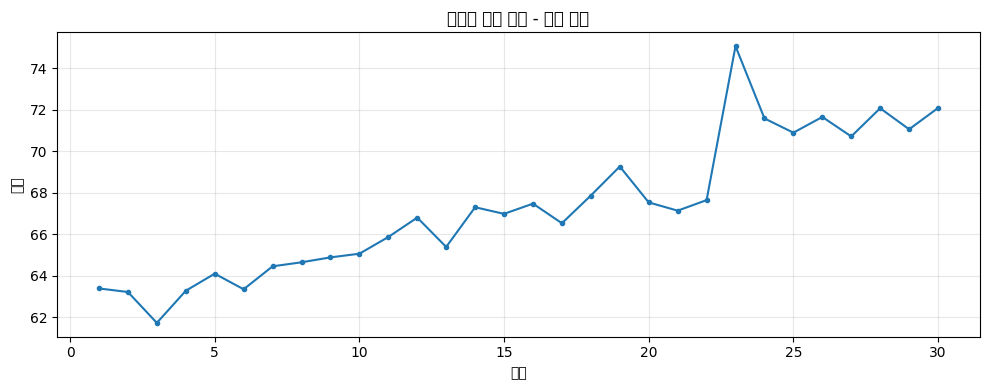

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(days, temperature, marker="o", markersize=3)
plt.title("일자별 온도 변화 - 해석 연습")
plt.xlabel("일자")
plt.ylabel("온도")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 🔍 무엇을 봐야 하나?
- 전체적으로 **우상향/우하향/평평**한가?
- 어느 지점부터 기울기가 달라지는가?
- 주변 흐름과 비교해 **한 점만 크게 튀는가?**
- 화면상 크게 보여도 실제 y축 숫자 차이는 얼마인가?

스파이크 1개만으로 고장이라고 단정하면 안 됩니다. 측정 오류·운전조건·다른 센서도 확인해야 합니다.

## 18-2. 막대 그래프 — 순위와 실제 차이

/tmp/ipykernel_860/3381125020.py:7: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/3381125020.py:7: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/3381125020.py:7: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/3381125020.py:7: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/3381125020.py:7: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/3381125020.py:7: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/3381125020.py:7: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/

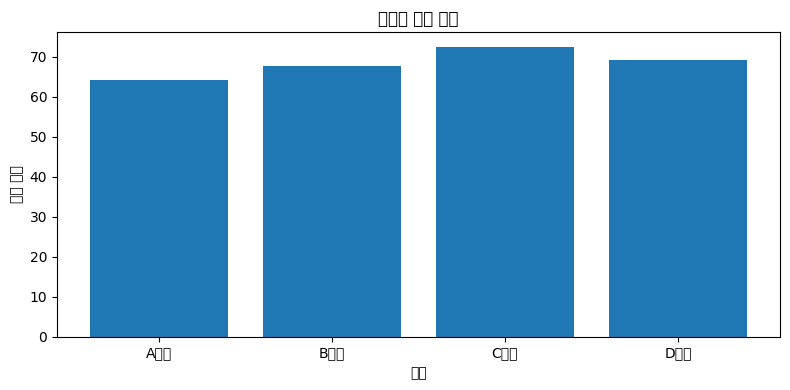

가장 높은 설비: C호기
최고-최저 차이: 8.3


In [ ]:
plt.figure(figsize=(8,4))
plt.bar(machines, avg_temp)
plt.title("설비별 평균 온도")
plt.xlabel("설비")
plt.ylabel("평균 온도")
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

print("가장 높은 설비:", machines[int(np.argmax(avg_temp))])
print("최고-최저 차이:", round(max(avg_temp)-min(avg_temp), 2))

### 🔍 무엇을 봐야 하나?
- 가장 높은/낮은 범주
- 1등과 2등 차이가 실제로 큰지
- y축 시작점이 차이를 과장하지 않는지

막대 길이로 크기를 비교할 때는 일반적으로 **0 기준선이 해석에 안전**합니다.

## 18-3. 히스토그램 — 중심 → 퍼짐 → 꼬리

/tmp/ipykernel_860/2541222949.py:6: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/2541222949.py:6: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/2541222949.py:6: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/2541222949.py:6: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/2541222949.py:6: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/2541222949.py:6: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu 

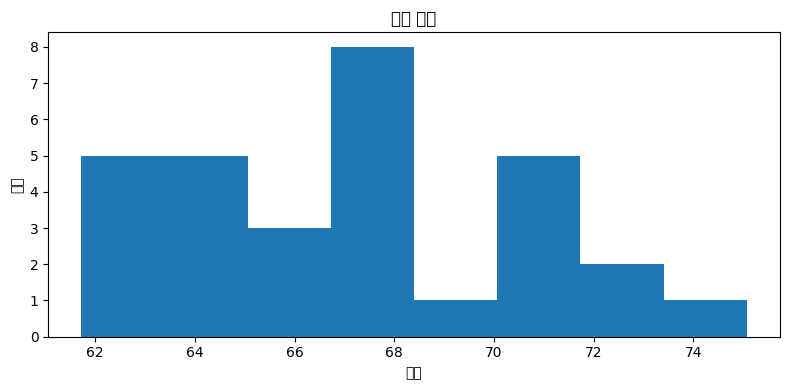

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(temperature, bins=8)
plt.title("온도 분포")
plt.xlabel("온도")
plt.ylabel("개수")
plt.tight_layout()
plt.show()

### 🔍 무엇을 봐야 하나?
- 어느 구간에 가장 많이 몰렸는가?
- 좁게 모였나, 넓게 퍼졌나?
- 한쪽 꼬리가 길게 늘어졌나?
- 동떨어진 값이 있는가?

`bins`에 따라 모양이 달라질 수 있으므로 한 가지 설정만 보고 결론 내리지 않는 편이 좋습니다.

## 18-4. 산점도 — 방향 → 밀집 → 동떨어진 점

/tmp/ipykernel_860/2223018351.py:6: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/2223018351.py:6: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/2223018351.py:6: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/2223018351.py:6: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/2223018351.py:6: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/2223018351.py:6: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/2223018351.py:6: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipy

/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


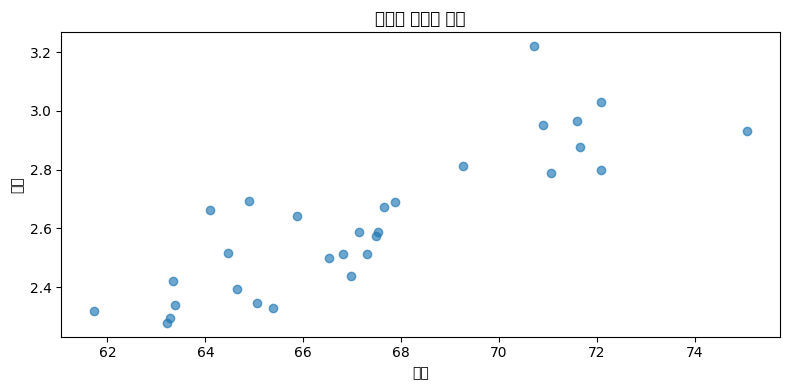

데모 상관계수: 0.851


In [ ]:
plt.figure(figsize=(8,4))
plt.scatter(temperature, vibration, alpha=0.65)
plt.title("온도와 진동의 관계")
plt.xlabel("온도")
plt.ylabel("진동")
plt.tight_layout()
plt.show()

r = np.corrcoef(temperature, vibration)[0,1]
print("데모 상관계수:", round(float(r), 3))

### 🔍 무엇을 봐야 하나?
- 우상향 → 양의 관계
- 우하향 → 음의 관계
- 넓게 흩어짐 → 선형 관계가 약할 수 있음
- 전체 흐름에서 멀리 떨어진 점 → 확인 후보

**상관관계는 인과관계가 아닙니다.**

## 18-5. 상황별 Matplotlib 선택표

| 상황 | 추천 코드 | 이유 |
|---|---|---|
| 시간 변화 | `plt.plot()` | 순서와 추세 |
| 설비별 비교 | `plt.bar()` | 범주 크기 비교 |
| 긴 범주 이름 | `plt.barh()` | 라벨 가독성 |
| 숫자 분포 | `plt.hist()` | 중심·퍼짐 |
| 숫자 2개 관계 | `plt.scatter()` | 관계 방향 |
| 기준선 | `plt.axhline()` / `axvline()` | 임계값 비교 |
| 여러 관점 한 화면 | `plt.subplots()` | 비교 리포트 |
| 점 겹침 | `alpha` 낮추기 | 밀집 영역 확인 |
| 긴 x축 글자 | `xticks(rotation=45)` | 겹침 방지 |

## 18-6. 자주 하는 해석 실수

1. **y축 범위에 속기** — 0.1 차이도 축을 좁히면 매우 커 보일 수 있음  
2. **단위가 다른 선을 한 축에 무리하게 겹치기** — 작은 센서가 납작해질 수 있음  
3. **선이 끊겼는데 이상으로 단정** — `NaN` 결측일 수 있음  
4. **색·마커를 너무 많이 사용** — 핵심 비교가 오히려 어려워짐

/tmp/ipykernel_860/3121790575.py:11: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/3121790575.py:11: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/3121790575.py:11: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/3121790575.py:11: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/3121790575.py:11: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/3121790575.py:11: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/3121790575.py:11: UserWarning: Glyph 48276 (\N{HANGUL SYLLABLE BEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()

/tmp/ipykernel_860/3121790575.py:11: UserWarning: Glyph 46160 (\N{HANGUL SYLLABLE DU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/3121790575.py:11: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/3121790575.py:11: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_860/3121790575.py:11: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48276 (\N{HANGUL SYLLABLE BEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46160 (\N{HANGUL SYLLABLE DU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


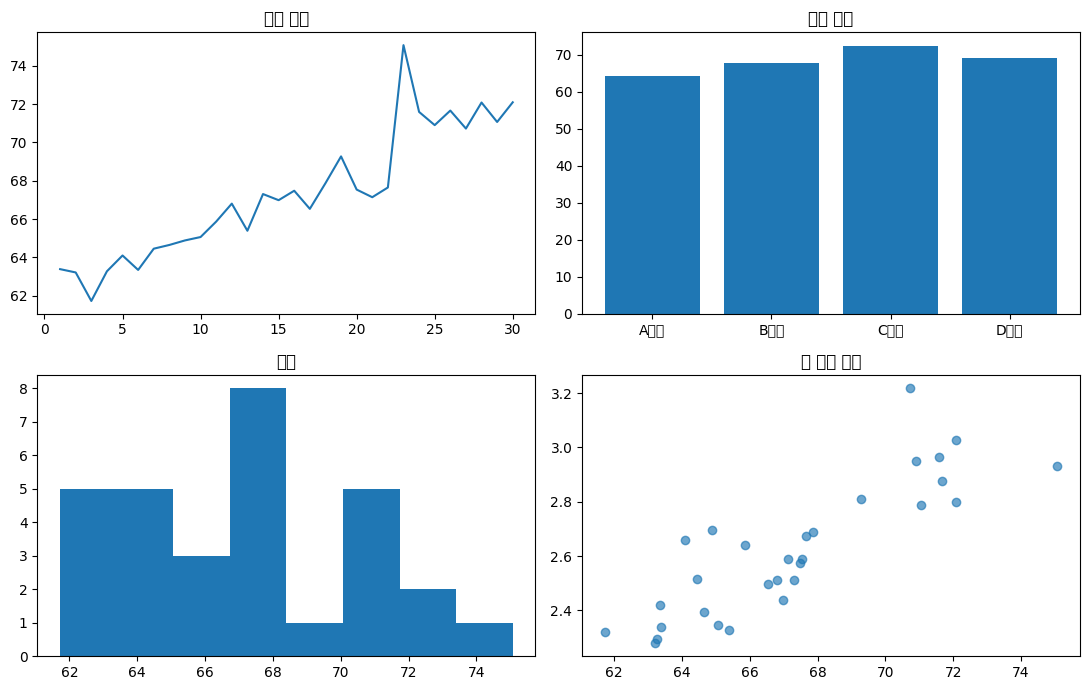

In [ ]:
fig, axes = plt.subplots(2,2,figsize=(11,7))
axes[0,0].plot(days, temperature)
axes[0,0].set_title("시간 변화")
axes[0,1].bar(machines, avg_temp)
axes[0,1].set_ylim(bottom=0)
axes[0,1].set_title("범주 비교")
axes[1,0].hist(temperature,bins=8)
axes[1,0].set_title("분포")
axes[1,1].scatter(temperature,vibration,alpha=0.65)
axes[1,1].set_title("두 변수 관계")
plt.tight_layout()
plt.show()

### 한 화면에서 질문을 나눠서 보기
- 시간 변화: **어떻게 변했나?**
- 막대: **어느 범주가 큰가?**
- 히스토그램: **어디에 몰렸나?**
- 산점도: **두 값이 함께 움직이나?**